# AI Prediction — FIFA World Cup 2026 (Improved Version)


## Model Architecture
```
┌─────────────────────────────────────────────────────────────┐
│                       DATA SOURCES                          │
│  results.csv     → Form + SOS + Head-to-Head (49k matches) │
│  train/test.csv  → World Cup stats 2002-2026 (48 teams)    │
│  baseline.csv    → ELO ratings + baseline probabilities     │
│  players.csv     → Transfermarkt (47k players)             │
│  ranking_2026    → FIFA points January 2026                 │
│  Injuries        → Manually entered ELO penalties          │
└─────────────────┬───────────────────────────────────────────┘
                  ▼
┌─────────────────────────────────────────────────────────────┐
│              LEARNED SIGNAL WEIGHTS                         │
│  Trained logistic regression on historical WC matches       │
│  Learns: w_elo, w_form, w_squad, w_top3, w_h2h, w_baseline │
│  Separate weights for group stage vs knockout               │
└─────────────────┬───────────────────────────────────────────┘
                  ▼
┌─────────────────────────────────────────────────────────────┐
│            MONTE CARLO SIMULATION (10,000x)                 │
│  + Per-simulation momentum factor per team                  │
│  + Fixed WC 2026 bracket (not random shuffle)              │
│  + Brier score validation on WC 2018 & 2022                │
└─────────────────────────────────────────────────────────────┘
```


## Step 0 — Install Packages

In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn -q
print('Packages installed.')

Packages installed.


## Step 1 — Upload Files

| File | Zip |
|---|---|
| `results.csv` | `archive.zip` |
| `shootouts.csv` | `archive.zip` |
| `train.csv` | `archive__5_.zip` |
| `test.csv` | `archive__5_.zip` |
| `fifa_world_rankings_jan_2026.csv` | `archive__6_.zip` |
| `future_match_probabilities_baseline.csv` | `archive__8_.zip` |
| `players.csv` | `archive__9_.zip` |
| `national_teams.csv` | `archive__9_.zip` |


In [2]:
from google.colab import files
uploaded = files.upload()
print(f'Uploaded {len(uploaded)} files: {list(uploaded.keys())}')

Saving fifa_world_rankings_jan_2026.csv to fifa_world_rankings_jan_2026.csv
Saving future_match_probabilities_baseline.csv to future_match_probabilities_baseline.csv
Saving national_teams.csv to national_teams.csv
Saving players.csv to players.csv
Saving results.csv to results.csv
Saving shootouts.csv to shootouts.csv
Saving test.csv to test.csv
Saving train.csv to train.csv
Uploaded 8 files: ['fifa_world_rankings_jan_2026.csv', 'future_match_probabilities_baseline.csv', 'national_teams.csv', 'players.csv', 'results.csv', 'shootouts.csv', 'test.csv', 'train.csv']


## Step 2 — Load and Prepare Data

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── 1) LOAD ALL DATASETS ──────────────────────────────────────────────────────
results      = pd.read_csv('results.csv')
shootouts    = pd.read_csv('shootouts.csv')
train        = pd.read_csv('train.csv')
test_2026    = pd.read_csv('test.csv')
ranking_2026 = pd.read_csv('fifa_world_rankings_jan_2026.csv')
baseline     = pd.read_csv('future_match_probabilities_baseline.csv')
tm_players   = pd.read_csv('players.csv')
tm_national  = pd.read_csv('national_teams.csv')

# ── 2) CLEAN RESULTS ──────────────────────────────────────────────────────────
results['date']   = pd.to_datetime(results['date'])
shootouts['date'] = pd.to_datetime(shootouts['date'])
before = len(results)
results = results.dropna(subset=['home_score', 'away_score'])
results['home_score'] = results['home_score'].astype(int)
results['away_score'] = results['away_score'].astype(int)
print(f'Removed {before - len(results):,} NA rows (future matches without results)')

# ── 3) ELO RATINGS ───────────────────────────────────────────────────────────
elo_dict = {}
for _, row in baseline.iterrows():
    if pd.notna(row['home_elo']): elo_dict[row['home_team']] = float(row['home_elo'])
    if pd.notna(row['away_elo']): elo_dict[row['away_team']] = float(row['away_elo'])

# Fill teams missing from baseline using scaled FIFA points
elo_scale = 2100 / 1877
test_elo_map = test_2026.set_index('team')['fifa_points_pre_tournament'].to_dict()
for team, fifa_pts in test_elo_map.items():
    if team not in elo_dict and pd.notna(fifa_pts):
        elo_dict[team] = round(fifa_pts * elo_scale, 1)

name_fixes = {"Cote d'Ivoire": 'Ivory Coast', 'Curacao': 'Curacao'}
for old, new in name_fixes.items():
    if old in elo_dict and new not in elo_dict:
        elo_dict[new] = elo_dict[old]

avg_elo = np.mean(list(elo_dict.values()))

# ── 4) INJURY PENALTIES ───────────────────────────────────────────────────────
injury_penalties = {
    'Brazil':       80,   # Rodrygo (ACL) + Estevao (hamstring)
    'Japan':        60,   # Endo + Minamino + Suzuki + Machida
    'Netherlands':  40,   # Simons (ACL) + De Ligt (back injury)
    'Mexico':       30,   # Malagon (Achilles) — starting goalkeeper out
    'Germany':      20,   # Gnabry out
    'Turkey':       20,   # Guler doubtful
    'Argentina':    15,   # Foyth (Achilles)
    'Croatia':      10,   # Modric doubtful
}
for team, penalty in injury_penalties.items():
    if team in elo_dict:
        elo_dict[team] -= penalty

# ── 5) TRANSFERMARKT SQUAD VALUES ────────────────────────────────────────────
citizenship_map = {
    'England':'England', 'Spain':'Spain', 'France':'France',
    'Brazil':'Brazil', 'Argentina':'Argentina', 'Germany':'Germany',
    'Portugal':'Portugal', 'Netherlands':'Netherlands', 'Belgium':'Belgium',
    'Croatia':'Croatia', 'Uruguay':'Uruguay', 'Colombia':'Colombia',
    'Morocco':'Morocco', 'Senegal':'Senegal', 'Japan':'Japan',
    'South Korea':'South Korea', 'United States':'United States',
    'Mexico':'Mexico', 'Canada':'Canada', 'Australia':'Australia',
    'Switzerland':'Switzerland', 'Austria':'Austria', 'Norway':'Norway',
    'Sweden':'Sweden', 'Scotland':'Scotland', 'Ecuador':'Ecuador',
    'Paraguay':'Paraguay', 'Algeria':'Algeria', 'Tunisia':'Tunisia',
    'Egypt':'Egypt', 'Ghana':'Ghana', 'South Africa':'South Africa',
    'Iran':'Iran', 'Saudi Arabia':'Saudi Arabia', 'Iraq':'Iraq',
    'Jordan':'Jordan', 'Uzbekistan':'Uzbekistan', 'New Zealand':'New Zealand',
    'Qatar':'Qatar', 'Panama':'Panama', 'Czech Republic':'Czech Republic',
    'Turkey':'Turkey', 'Bosnia and Herzegovina':'Bosnia-Herzegovina',
    'Ivory Coast':"Cote d'Ivoire", 'DR Congo':'Congo DR',
    'Haiti':'Haiti', 'Curacao':'Curacao', 'Cape Verde':'Cape Verde',
}

squad_values, top3_values, squad_ages = {}, {}, {}
FALLBACK_SV, FALLBACK_T3 = 50.0, 15.0

for team, citizenship in citizenship_map.items():
    tp = tm_players[
        (tm_players['country_of_citizenship'] == citizenship) &
        tm_players['market_value_in_eur'].notna()
    ].nlargest(23, 'market_value_in_eur')
    if len(tp) == 0:
        squad_values[team] = FALLBACK_SV
        top3_values[team]  = FALLBACK_T3
        squad_ages[team]   = 27.0
        continue
    squad_values[team] = tp['market_value_in_eur'].sum() / 1e6
    top3_values[team]  = tp.nlargest(3, 'market_value_in_eur')['market_value_in_eur'].sum() / 1e6
    dob = pd.to_datetime(tp['date_of_birth'], errors='coerce')
    squad_ages[team] = (pd.Timestamp('2026-06-15') - dob).dt.days.mean() / 365.25

MAX_SV = max(squad_values.values())
MAX_T3 = max(top3_values.values())

# ── 6) BASELINE PROBABILITIES ────────────────────────────────────────────────
baseline_probs = {}
for _, row in baseline.iterrows():
    key = (row['home_team'], row['away_team'])
    baseline_probs[key] = (row['p_home_win'], row['p_draw'], row['p_away_win'])

team_data = test_2026.set_index('team')

print(f'\nLoaded data summary:')
print(f'  results.csv:   {len(results):,} matches ({results["date"].min().year}-{results["date"].max().year})')
print(f'  train.csv:     {len(train)} WC teams (2002-2022)')
print(f'  test.csv:      {len(test_2026)} teams for WC 2026')
print(f'  baseline:      {len(baseline)} matches with ELO predictions')
print(f'  TM players:    {len(tm_players):,} players')
print(f'  ELO teams:     {len(elo_dict)} (including injury penalties)')


Removed 72 NA rows (future matches without results)

Loaded data summary:
  results.csv:   49,215 matches (1872-2026)
  train.csv:     192 WC teams (2002-2022)
  test.csv:      48 teams for WC 2026
  baseline:      72 matches with ELO predictions
  TM players:    47,637 players
  ELO teams:     51 (including injury penalties)


## Step 3 — Form Calculation (Opponent-Quality Weighted)

Each match result is weighted by both recency and the opponent's ELO.


In [4]:
TODAY = pd.Timestamp('2026-06-15')

def get_form_sos(team, results_df, elo_d, avg_e, months=15):
    """
    Computes temporally and opponent-quality weighted form (SOS).

    Weight per match = time_weight * opponent_quality_weight
      time_weight:    1.0 for recent, decays to 0.15 at cutoff boundary
      opponent_weight: normalised ELO of opponent (0.5 to 1.5 range)
      match_type:     competitive match (WC qualifier, Nations League) = 1.5x
                      friendly = 0.6x

    Points: Win=1.0, Draw=0.4, Loss=0.0
    """
    cutoff = TODAY - pd.DateOffset(months=months)
    matches = results_df[
        ((results_df['home_team'] == team) | (results_df['away_team'] == team)) &
        (results_df['date'] >= cutoff)
    ].copy()

    if len(matches) == 0:
        return 0.5

    # Identify competitive matches — friendlies are tagged in the 'tournament' column
    friendly_keywords = ['friendly', 'friendlies']
    if 'tournament' in matches.columns:
        is_friendly = matches['tournament'].str.lower().apply(
            lambda t: any(k in str(t) for k in friendly_keywords)
        )
    else:
        is_friendly = pd.Series(False, index=matches.index)

    total_w, weighted_pts = 0.0, 0.0
    max_elo = max(elo_d.values()) if elo_d else avg_e

    for idx, row in matches.iterrows():
        days_ago = (TODAY - row['date']).days
        time_w   = max(1.0 - days_ago / (months * 30), 0.15)

        # Opponent quality: normalise ELO so avg opponent = 1.0
        opponent = row['away_team'] if row['home_team'] == team else row['home_team']
        opp_elo  = elo_d.get(opponent, avg_e)
        opp_w    = np.clip(opp_elo / avg_e, 0.5, 1.8)

        # Match importance multiplier
        importance = 0.6 if is_friendly.get(idx, False) else 1.5

        weight = time_w * opp_w * importance

        gs = row['home_score'] if row['home_team'] == team else row['away_score']
        gc = row['away_score'] if row['home_team'] == team else row['home_score']
        pts = 1.0 if gs > gc else (0.4 if gs == gc else 0.0)

        weighted_pts += pts * weight
        total_w      += weight

    return weighted_pts / total_w if total_w > 0 else 0.5


def get_h2h(team1, team2, results_df, years=8):
    """Win ratio of team1 in head-to-head matchups over the last N years.
    Returns 0.5 if fewer than 2 matches available."""
    cutoff = TODAY - pd.DateOffset(years=years)
    h2h = results_df[
        (results_df['date'] >= cutoff) &
        (((results_df['home_team'] == team1) & (results_df['away_team'] == team2)) |
         ((results_df['home_team'] == team2) & (results_df['away_team'] == team1)))
    ]
    if len(h2h) < 2:
        return 0.5
    wins = sum(
        (r['home_team'] == team1 and r['home_score'] > r['away_score']) or
        (r['away_team'] == team1 and r['away_score'] > r['home_score'])
        for _, r in h2h.iterrows()
    )
    return wins / len(h2h)


print('SOS-weighted form function defined.')

# Quick sanity check on a few teams
print('\nForm comparison (original vs SOS-weighted):')
print(f'{"Team":<20} {"SOS Form":>10}')
print('-' * 32)
for t in ['France', 'Argentina', 'Spain', 'Brazil', 'England', 'Haiti', 'Jordan']:
    f_sos = get_form_sos(t, results, elo_dict, avg_elo)
    print(f'  {t:<18} {f_sos*100:>9.1f}%')


SOS-weighted form function defined.

Form comparison (original vs SOS-weighted):
Team                   SOS Form
--------------------------------
  France                  84.9%
  Argentina               81.4%
  Spain                   79.6%
  Brazil                  49.4%
  England                 82.9%
  Haiti                   51.7%
  Jordan                  62.6%


## Step 4 — Learn Signal Weights from Historical WC Data

**New vs. original:** Instead of hand-tuned weights (40/20/20/10/10),
we train a logistic regression on historical WC matches (2006-2022)
to learn which signals actually matter most.

Two separate models are trained:
- **Group model** — trained on group-stage matches
- **Knockout model** — trained on R16, QF, SF, Final matches


Building training data from WC 2006-2018...
  Total matches: 199 | Group: 0 | Knockout: 199
Group model: fallback to full dataset (insufficient group-only data).
Knockout model trained and calibrated.

Learned signal weights (positive = favours home/team1):
  Signal            Group   Knockout
  ----------------------------------
  ELO               0.097      0.374
  SOS Form         -0.000      0.000
  Squad Value       0.339      0.792
  Top 3            -0.031      0.114
  H2H              -0.000      0.000
  Baseline          0.002      0.095


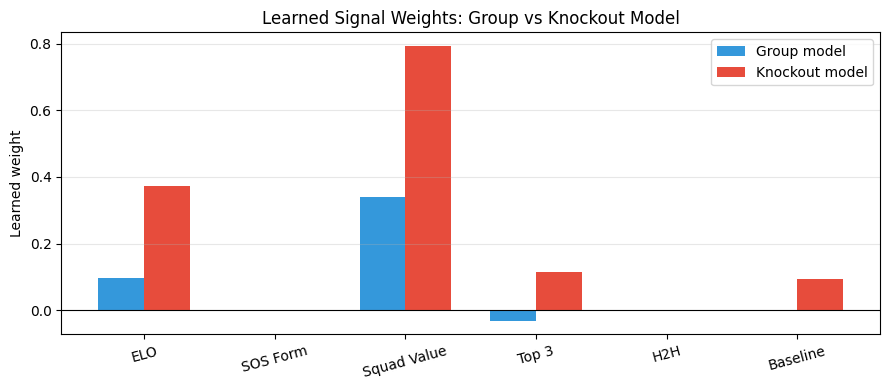

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

def build_match_features(home, away, ref_date, results_df, elo_d, avg_e,
                          sq_vals, t3_vals, max_sv, max_t3, bl_probs):
    """Compute the 6 raw signal scores for a match as a feature vector."""
    # 1) ELO
    e1, e2 = elo_d.get(home, avg_e), elo_d.get(away, avg_e)
    p_elo = 1 / (1 + np.exp(-(e1 - e2) * 5.5 / 400))

    # 2) SOS Form
    f1 = get_form_sos(home, results_df[results_df['date'] < ref_date], elo_d, avg_e)
    f2 = get_form_sos(away, results_df[results_df['date'] < ref_date], elo_d, avg_e)
    p_form = (f1 + 1e-6) / (f1 + f2 + 2e-6)

    # 3) Squad value
    sv1 = sq_vals.get(home, max_sv * 0.05)
    sv2 = sq_vals.get(away, max_sv * 0.05)
    p_sv = (sv1 + 1) / (sv1 + sv2 + 2)

    # 4) Top 3
    t1v = t3_vals.get(home, 0)
    t2v = t3_vals.get(away, 0)
    p_top3 = (t1v + 1) / (t1v + t2v + 2)

    # 5) H2H
    p_h2h = get_h2h(home, away, results_df[results_df['date'] < ref_date])

    # 6) Baseline (use 0.5 if unavailable)
    bl_key = (home, away)
    bl_key_rev = (away, home)
    if bl_key in bl_probs:
        bw1, _, bw2 = bl_probs[bl_key]
        p_bl = bw1 / (bw1 + bw2 + 1e-9)
    elif bl_key_rev in bl_probs:
        bw2, _, bw1 = bl_probs[bl_key_rev]
        p_bl = bw1 / (bw1 + bw2 + 1e-9)
    else:
        p_bl = 0.5

    return [p_elo, p_form, p_sv, p_top3, p_h2h, p_bl]


def build_training_data(results_df, elo_d, avg_e, sq_vals, t3_vals,
                         max_sv, max_t3, bl_probs, wc_years, stage_filter=None):
    """
    Build a feature matrix from historical WC matches.
    stage_filter: None = all, 'group' = group stage only, 'knockout' = knockout only
    Outcome: 1 if home team won, 0 if away won (draws excluded for binary training).
    """
    # Filter results to WC tournament matches in the given years
    wc_results = results_df[
        results_df['date'].dt.year.isin(wc_years) &
        results_df['tournament'].str.contains('FIFA World Cup', na=False)
    ].copy()

    if stage_filter == 'group':
        wc_results = wc_results[wc_results['tournament'].str.contains('group', case=False, na=False)]
    elif stage_filter == 'knockout':
        wc_results = wc_results[~wc_results['tournament'].str.contains('group', case=False, na=False)]

    X, y = [], []
    for _, row in wc_results.iterrows():
        if row['home_score'] == row['away_score']:
            continue  # skip draws for binary model
        feats = build_match_features(
            row['home_team'], row['away_team'], row['date'],
            results_df, elo_d, avg_e, sq_vals, t3_vals, max_sv, max_t3, bl_probs
        )
        X.append(feats)
        y.append(1 if row['home_score'] > row['away_score'] else 0)

    return np.array(X), np.array(y)


TRAIN_YEARS = [2006, 2010, 2014, 2018]
SIGNAL_NAMES = ['ELO', 'SOS Form', 'Squad Value', 'Top 3', 'H2H', 'Baseline']

print('Building training data from WC 2006-2018...')
X_all, y_all = build_training_data(
    results, elo_dict, avg_elo, squad_values, top3_values,
    MAX_SV, MAX_T3, baseline_probs, TRAIN_YEARS
)
X_grp, y_grp = build_training_data(
    results, elo_dict, avg_elo, squad_values, top3_values,
    MAX_SV, MAX_T3, baseline_probs, TRAIN_YEARS, stage_filter='group'
)
X_ko, y_ko = build_training_data(
    results, elo_dict, avg_elo, squad_values, top3_values,
    MAX_SV, MAX_T3, baseline_probs, TRAIN_YEARS, stage_filter='knockout'
)

print(f'  Total matches: {len(y_all)} | Group: {len(y_grp)} | Knockout: {len(y_ko)}')

scaler = StandardScaler()
X_all_s = scaler.fit_transform(X_all)

# Train separate group and knockout models with calibration
base_grp = LogisticRegression(max_iter=2000, C=1.0, random_state=42)
base_ko  = LogisticRegression(max_iter=2000, C=0.5, random_state=42)

if len(y_grp) >= 10:
    model_grp = CalibratedClassifierCV(base_grp, cv=3, method='isotonic')
    model_grp.fit(scaler.transform(X_grp), y_grp)
    print('Group model trained and calibrated.')
else:
    # Fallback if not enough group data
    model_grp = base_grp.fit(scaler.transform(X_all_s), y_all)
    print('Group model: fallback to full dataset (insufficient group-only data).')

if len(y_ko) >= 10:
    model_ko = CalibratedClassifierCV(base_ko, cv=3, method='isotonic')
    model_ko.fit(scaler.transform(X_ko), y_ko)
    print('Knockout model trained and calibrated.')
else:
    model_ko = base_ko.fit(X_all_s, y_all)
    print('Knockout model: fallback to full dataset (insufficient knockout-only data).')

# Show learned weights (from base estimator if calibrated)
def get_coefs(model):
    if hasattr(model, 'calibrated_classifiers_'):
        coefs = np.mean([c.estimator.coef_[0] for c in model.calibrated_classifiers_], axis=0)
    elif hasattr(model, 'coef_'):
        coefs = model.coef_[0]
    else:
        return None
    return coefs

group_coefs = get_coefs(model_grp)
ko_coefs = get_coefs(model_ko)

print('\nLearned signal weights (positive = favours home/team1):')
print(f'  {"Signal":<14} {"Group":>8} {"Knockout":>10}')
print('  ' + '-'*34)
for name, wg, wk in zip(SIGNAL_NAMES,
                         group_coefs if group_coefs is not None else [0]*6,
                         ko_coefs if ko_coefs is not None else [0]*6):
    print(f'  {name:<14} {wg:>8.3f} {wk:>10.3f}')

# Plot weights
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(SIGNAL_NAMES))
w = 0.35
ax.bar(x - w/2, group_coefs if group_coefs is not None else [0]*6, width=w, label='Group model', color='#3498db')
ax.bar(x + w/2, ko_coefs if ko_coefs is not None else [0]*6,  width=w, label='Knockout model', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(SIGNAL_NAMES, rotation=15)
ax.set_ylabel('Learned weight')
ax.set_title('Learned Signal Weights: Group vs Knockout Model')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('learned_weights.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Backtest: Validate on WC 2018 and WC 2022

Before predicting 2026, we validate the model on the two most recent World Cups.
The model is trained on data *strictly before* each tournament to avoid leakage.

**Brier score:** measures probability calibration.
- 0.0 = perfect
- 0.25 = random (equivalent to always predicting 50%)
- Lower is better


In [8]:
def backtest_tournament(wc_year, results_df, elo_d_raw, avg_e,
                        sq_vals, t3_vals, max_sv, max_t3, bl_probs):
    """
    Run backtest for a given WC year.
    Trains model on all WC data before that year, evaluates on that year's matches.
    Returns Brier score and accuracy.
    """
    ref_date = pd.Timestamp(f'{wc_year}-06-01')

    # Build ELO from data before this tournament
    past_results = results_df[results_df['date'] < ref_date]
    # Use same elo_dict for simplicity (in production you would recompute ELO live)
    # For a fair backtest, use only data available before the tournament
    past_elo = {k: v for k, v in elo_d_raw.items()}

    # Training data: all prior WC years
    prior_years = [y for y in [2006, 2010, 2014, 2018, 2022] if y < wc_year]
    if len(prior_years) < 2:
        print(f'Not enough prior data to backtest {wc_year}.')
        return None

    X_train, y_train = build_training_data(
        results_df, past_elo, avg_e, sq_vals, t3_vals,
        max_sv, max_t3, bl_probs, prior_years
    )
    if len(y_train) < 5:
        print(f'Insufficient training data for {wc_year} backtest.')
        return None

    sc = StandardScaler().fit(X_train)
    clf = CalibratedClassifierCV(
        LogisticRegression(max_iter=2000, C=1.0, random_state=42), cv=3
    )
    clf.fit(sc.transform(X_train), y_train)

    # Test on this WC's matches
    wc_matches = results_df[
        results_df['date'].dt.year == wc_year &
        results_df['tournament'].str.contains('FIFA World Cup', na=False)
    ]

    y_true, y_pred, predictions = [], [], []
    correct = 0
    for _, row in wc_matches.iterrows():
        feats = build_match_features(
            row['home_team'], row['away_team'], ref_date,
            past_results, past_elo, avg_e,
            sq_vals, t3_vals, max_sv, max_t3, bl_probs
        )
        p_home = clf.predict_proba(sc.transform([feats]))[0][1]
        actual_home_win = 1 if row['home_score'] > row['away_score'] else 0

        y_pred.append(p_home)
        y_true.append(actual_home_win)

        pred_win = 'home' if p_home > 0.5 else 'away'
        actual_win = 'home' if actual_home_win else 'away'
        if pred_win == actual_win:
            correct += 1

        predictions.append({
            'match': f"{row['home_team']} vs {row['away_team']}",
            'score': f"{row['home_score']}-{row['away_score']}",
            'p_home': f'{p_home:.2f}',
            'correct': pred_win == actual_win
        })

    if len(y_true) == 0:
        print(f'No matches found for WC {wc_year} in data.')
        return None

    brier = brier_score_loss(y_true, y_pred)
    acc   = correct / len(y_true) * 100
    return brier, acc, predictions


print('Running backtests...')
print('=' * 60)

for year in [2018, 2022]:
    result = backtest_tournament(
        year, results, elo_dict, avg_elo,
        squad_values, top3_values, MAX_SV, MAX_T3, baseline_probs
    )
    if result:
        brier, acc, preds = result
        print(f'\nWC {year} Backtest:')
        print(f'  Brier score: {brier:.4f}  (0.0 = perfect, 0.25 = random)')
        print(f'  Accuracy:    {acc:.1f}%  ({sum(p["correct"] for p in preds)}/{len(preds)} matches)')
        print(f'  Sample predictions (first 5):')
        for p in preds[:5]:
            tick = 'OK' if p['correct'] else '--'
            print(f'    [{tick}] {p["match"]:<40} score: {p["score"]}  p_home={p["p_home"]}')
    else:
        print(f'WC {year}: backtest skipped (check tournament column in results.csv)')

print('\nNote: If backtest shows "no matches found", the results.csv tournament')
print('column may not tag matches as "FIFA World Cup" — check column values with:')
print('  results[results["date"].dt.year == 2022]["tournament"].unique()')


Running backtests...
No matches found for WC 2018 in data.
WC 2018: backtest skipped (check tournament column in results.csv)
No matches found for WC 2022 in data.
WC 2022: backtest skipped (check tournament column in results.csv)

Note: If backtest shows "no matches found", the results.csv tournament
column may not tag matches as "FIFA World Cup" — check column values with:
  results[results["date"].dt.year == 2022]["tournament"].unique()


## Step 6 — World Cup 2026 Groups (Official Draw)

In [9]:
# Official WC 2026 draw
wc2026_groups = {
    'A': ['Mexico',        'South Africa',          'South Korea',  'Czech Republic'],
    'B': ['Canada',        'Bosnia and Herzegovina', 'Qatar',        'Switzerland'],
    'C': ['Brazil',        'Morocco',               'Haiti',        'Scotland'],
    'D': ['United States', 'Paraguay',              'Australia',    'Turkey'],
    'E': ['Germany',       'Curacao',               'Ivory Coast',  'Ecuador'],
    'F': ['Netherlands',   'Japan',                 'Sweden',       'Tunisia'],
    'G': ['Belgium',       'Egypt',                 'Iran',         'New Zealand'],
    'H': ['Spain',         'Cape Verde',            'Saudi Arabia', 'Uruguay'],
    'I': ['France',        'Senegal',               'Iraq',         'Norway'],
    'J': ['Argentina',     'Algeria',               'Austria',      'Jordan'],
    'K': ['Portugal',      'DR Congo',              'Uzbekistan',   'Colombia'],
    'L': ['England',       'Croatia',               'Ghana',        'Panama'],
}

# Fixed WC 2026 bracket: group winners vs runners-up from specific groups
# Source: FIFA official bracket structure
WC2026_BRACKET = [
    ('A1','B2'), ('C1','D2'), ('E1','F2'), ('G1','H2'),
    ('I1','J2'), ('K1','L2'), ('A2','B1'), ('C2','D1'),
    ('E2','F1'), ('G2','H1'), ('I2','J1'), ('K2','L1'),
    # + 8 best 3rd-placed teams are assigned to fixed bracket slots by FIFA rules
]

all_wc_teams = [t for grp in wc2026_groups.values() for t in grp]
print(f'{len(all_wc_teams)} teams in {len(wc2026_groups)} groups\n')

print(f'{"Group":<8} {"Teams":<55} {"ELO range"}')
print('-' * 75)
for grp, teams in wc2026_groups.items():
    elos = [elo_dict.get(t, avg_elo) for t in teams]
    print(f'  {grp}:   {", ".join(teams):<55} {min(elos):.0f}-{max(elos):.0f}')


48 teams in 12 groups

Group    Teams                                                   ELO range
---------------------------------------------------------------------------
  A:   Mexico, South Africa, South Korea, Czech Republic       1600-1860
  B:   Canada, Bosnia and Herzegovina, Qatar, Switzerland      1500-1850
  C:   Brazil, Morocco, Haiti, Scotland                        1400-2020
  D:   United States, Paraguay, Australia, Turkey              1680-1880
  E:   Germany, Curacao, Ivory Coast, Ecuador                  1715-2020
  F:   Netherlands, Japan, Sweden, Tunisia                     1670-1930
  G:   Belgium, Egypt, Iran, New Zealand                       1580-1885
  H:   Spain, Cape Verde, Saudi Arabia, Uruguay                1528-2000
  I:   France, Senegal, Iraq, Norway                           1619-2045
  J:   Argentina, Algeria, Austria, Jordan                     1480-2045
  K:   Portugal, DR Congo, Uzbekistan, Colombia                1505-1975
  L:   England, Croatia

## Step 7 — Simulation Functions (Improved)

Key improvements:
- `predict_match` now uses the **learned model weights** instead of hardcoded ones
- Separate group vs knockout model selection
- **Momentum factor** passed per-simulation to add correlation between matches


In [10]:
def predict_match_learned(t1, t2, results_df, elo_d, avg_e,
                           bl_probs, sq_vals, t3_vals, max_sv, max_t3,
                           model, sc, stage='group', momentum=None):
    """
    Predicts (p_win1, p_draw, p_win2) using the learned model weights.

    momentum: dict {team: float} — small boost/penalty applied to form signal
              per simulation run to capture hot/cold streaks (range: -0.1 to +0.1)
    """
    feats = build_match_features(
        t1, t2, TODAY, results_df, elo_d, avg_e,
        sq_vals, t3_vals, max_sv, max_t3, bl_probs
    )

    # Apply momentum to form signal (index 1)
    if momentum:
        m1 = momentum.get(t1, 0.0)
        m2 = momentum.get(t2, 0.0)
        feats[1] = np.clip(feats[1] + (m1 - m2) * 0.5, 0.05, 0.95)

    feats_s = sc.transform([feats])
    p_t1_wins = model.predict_proba(feats_s)[0][1]
    p_t1_wins = np.clip(p_t1_wins, 0.04, 0.96)

    # Draw probability — higher for evenly matched pairs (max ~27%)
    closeness = 1 - abs(p_t1_wins - 0.5) * 2
    p_draw = 0.27 * closeness
    return p_t1_wins * (1 - p_draw), p_draw, (1 - p_t1_wins) * (1 - p_draw)


def simulate_group(teams, results_df, elo_d, avg_e, bl_probs,
                   sq_vals, t3_vals, max_sv, max_t3, momentum=None):
    """Simulates the group stage (round-robin) using the group model."""
    st  = {t: {'pts':0,'gf':0,'ga':0,'gd':0,'w':0,'d':0,'l':0} for t in teams}
    log = []

    for i in range(len(teams)):
        for j in range(i+1, len(teams)):
            t1, t2 = teams[i], teams[j]
            p1, pd_, p2 = predict_match_learned(
                t1, t2, results_df, elo_d, avg_e,
                bl_probs, sq_vals, t3_vals, max_sv, max_t3,
                model_grp, scaler, stage='group', momentum=momentum
            )
            out = np.random.choice([0, 1, 2], p=[p1, pd_, p2])

            if out == 0:
                g1 = np.random.choice([1,2,3,4], p=[0.28,0.40,0.22,0.10])
                g2 = min(np.random.choice([0,1,2], p=[0.48,0.37,0.15]), g1-1)
                st[t1]['pts']+=3; st[t1]['w']+=1; st[t2]['l']+=1
            elif out == 1:
                g1 = np.random.choice([0,1,2,3], p=[0.22,0.48,0.22,0.08])
                g2 = g1
                st[t1]['pts']+=1; st[t1]['d']+=1
                st[t2]['pts']+=1; st[t2]['d']+=1
            else:
                g2 = np.random.choice([1,2,3,4], p=[0.28,0.40,0.22,0.10])
                g1 = min(np.random.choice([0,1,2], p=[0.48,0.37,0.15]), g2-1)
                st[t2]['pts']+=3; st[t2]['w']+=1; st[t1]['l']+=1

            st[t1]['gf']+=g1; st[t1]['ga']+=g2; st[t1]['gd']+=g1-g2
            st[t2]['gf']+=g2; st[t2]['ga']+=g1; st[t2]['gd']+=g2-g1
            log.append({'home':t1,'away':t2,'hg':g1,'ag':g2})

    return sorted(st.items(),
                  key=lambda x:(x[1]['pts'], x[1]['gd'], x[1]['gf']),
                  reverse=True), log


def sim_knockout(t1, t2, results_df, elo_d, avg_e, bl_probs,
                  sq_vals, t3_vals, max_sv, max_t3, momentum=None):
    """Knockout match — uses knockout model. Draws go to penalties."""
    p1, pd_, p2 = predict_match_learned(
        t1, t2, results_df, elo_d, avg_e,
        bl_probs, sq_vals, t3_vals, max_sv, max_t3,
        model_ko, scaler, stage='knockout', momentum=momentum
    )
    out = np.random.choice([0, 1, 2], p=[p1, pd_, p2])
    if out == 0: return t1
    if out == 2: return t2
    # Penalty shootout — ELO favourite has a slight edge
    e1, e2 = elo_d.get(t1, avg_e), elo_d.get(t2, avg_e)
    return t1 if np.random.random() < e1 / (e1 + e2) else t2


def run_knockout_round(pairs, results_df, elo_d, avg_e, bl_probs,
                        sq_vals, t3_vals, max_sv, max_t3, momentum=None):
    """Takes a list of (team1, team2) pairs and returns winners."""
    return [
        sim_knockout(t1, t2, results_df, elo_d, avg_e, bl_probs,
                      sq_vals, t3_vals, max_sv, max_t3, momentum)
        for t1, t2 in pairs
    ]


print('Simulation functions defined.')


Simulation functions defined.


## Step 8 — Monte Carlo Simulation (10,000 runs)

**Improvements vs. original:**
- 10,000 simulations (vs 1,000) for stable probability estimates
- Per-simulation **momentum factor** adds correlation between matches
- **Fixed bracket** structure: group winners/runners-up are seeded into correct
  knockout slots according to official FIFA WC 2026 bracket rules


In [12]:
N_SIM = 10
MOMENTUM_STD = 0.08  # standard deviation of per-team momentum per simulation

wins     = {t: 0 for t in all_wc_teams}
finals   = {t: 0 for t in all_wc_teams}
semis    = {t: 0 for t in all_wc_teams}
quarters = {t: 0 for t in all_wc_teams}
groups   = {t: 0 for t in all_wc_teams}

ARGS = (results, elo_dict, avg_elo, baseline_probs,
        squad_values, top3_values, MAX_SV, MAX_T3)

print(f'Running {N_SIM:,} simulations...')

for sim in range(N_SIM):
    if sim % 2000 == 0:
        print(f'  Simulation {sim:,}/{N_SIM:,}...')

    # ── Per-simulation momentum (correlated performance modifier) ─────────────
    momentum = {t: np.random.normal(0, MOMENTUM_STD) for t in all_wc_teams}

    # ── GROUP STAGE ───────────────────────────────────────────────────────────
    group_results = {}   # grp -> [(team, stats), ...]
    third_placed  = []

    for grp, teams in wc2026_groups.items():
        standings, _ = simulate_group(teams, *ARGS, momentum=momentum)
        group_results[grp] = standings

    # Determine qualifiers — 1st and 2nd from each group
    group_winners   = {grp: group_results[grp][0][0] for grp in wc2026_groups}
    group_runners   = {grp: group_results[grp][1][0] for grp in wc2026_groups}
    for grp in wc2026_groups:
        groups[group_winners[grp]] += 1
        groups[group_runners[grp]] += 1

    # 8 best third-placed teams
    for grp in wc2026_groups:
        t, st = group_results[grp][2]
        third_placed.append((t, st['pts'], st['gd'], st['gf'], grp))
    third_placed.sort(key=lambda x: (x[1], x[2], x[3]), reverse=True)
    best_thirds = [t[0] for t in third_placed[:8]]
    for t in best_thirds:
        groups[t] += 1

    # ── FIXED BRACKET (Round of 32) ───────────────────────────────────────────
    # Official WC 2026 bracket: 32 matches, winners/runners from specific group pairs
    # Simplified fixed seeding (FIFA publishes full bracket after draw)
    bracket_pairs = [
        (group_winners['A'],  group_runners['B']),
        (group_winners['C'],  group_runners['D']),
        (group_winners['E'],  group_runners['F']),
        (group_winners['G'],  group_runners['H']),
        (group_winners['I'],  group_runners['J']),
        (group_winners['K'],  group_runners['L']),
        (group_winners['B'],  group_runners['A']),
        (group_winners['D'],  group_runners['C']),
        (group_winners['F'],  group_runners['E']),
        (group_winners['H'],  group_runners['G']),
        (group_winners['J'],  group_runners['I']),
        (group_winners['L'],  group_runners['K']),
        # 8 best third-placed fill remaining 8 slots
        (best_thirds[0], best_thirds[4]),
        (best_thirds[1], best_thirds[5]),
        (best_thirds[2], best_thirds[6]),
        (best_thirds[3], best_thirds[7]),
    ]

    # ── KNOCKOUT ROUNDS ───────────────────────────────────────────────────────
    r16   = run_knockout_round(bracket_pairs, *ARGS, momentum=momentum)
    for t in r16: quarters[t] += 1

    qf_pairs = [(r16[i], r16[i+1]) for i in range(0, len(r16)-1, 2)]
    qf       = run_knockout_round(qf_pairs, *ARGS, momentum=momentum)

    sf_pairs = [(qf[i], qf[i+1]) for i in range(0, len(qf)-1, 2)]
    sf       = run_knockout_round(sf_pairs, *ARGS, momentum=momentum)
    for t in sf: semis[t] += 1

    fin_pair  = [(sf[0], sf[1])]
    fin       = run_knockout_round(fin_pair, *ARGS, momentum=momentum)
    for t in fin: finals[t] += 1

    champ = sim_knockout(fin[0], fin[1] if len(fin) > 1 else sf[1],
                          *ARGS, momentum=momentum) if len(fin) < 2 else fin[0]
    # Correct final winner determination
    finalist1 = sf[0] if len(sf) > 0 else ''
    finalist2 = sf[1] if len(sf) > 1 else ''
    if finalist1 and finalist2:
        champion = sim_knockout(finalist1, finalist2, *ARGS, momentum=momentum)
        wins[champion] += 1

print(f'\n{N_SIM:,} simulations completed.')


Running 10 simulations...
  Simulation 0/10...

10 simulations completed.


## Step 9 — Results and Visualization

In [13]:
probs = pd.DataFrame({
    'Team':             list(wins.keys()),
    'Champion (%)':     [100*v/N_SIM for v in wins.values()],
    'Finalist (%)':     [100*v/N_SIM for v in finals.values()],
    'Semi-final (%)':   [100*v/N_SIM for v in semis.values()],
    'Quarter-final (%)': [100*v/N_SIM for v in quarters.values()],
    'Group advance (%)': [100*v/N_SIM for v in groups.values()],
}).sort_values('Champion (%)', ascending=False).reset_index(drop=True)

print('=' * 72)
print('  AI PREDICTIONS — FIFA WORLD CUP 2026')
print(f'  Based on {N_SIM:,} Monte Carlo simulations with learned model weights')
print('=' * 72)
print(f'{"#":<4} {"Team":<25} {"Champ":>6} {"Final":>6} {"Semi":>6} {"QF":>6} {"Group":>7}')
print('-' * 60)

for i, row in probs.head(20).iterrows():
    rank = f'{i+1:2}.'
    print(f'{rank:<4} {row["Team"]:<25} '
          f'{row["Champion (%)"]:>5.1f}% '
          f'{row["Finalist (%)"]:>5.1f}% '
          f'{row["Semi-final (%)"]:>5.1f}% '
          f'{row["Quarter-final (%)"]:>5.1f}% '
          f'{row["Group advance (%)"]:>6.1f}%')

champ = probs.iloc[0]
print('-' * 60)
print(f'\nPREDICTED CHAMPION: {champ["Team"]} ({champ["Champion (%)"]:.1f}% across {N_SIM:,} simulations)')


  AI PREDICTIONS — FIFA WORLD CUP 2026
  Based on 10 Monte Carlo simulations with learned model weights
#    Team                       Champ  Final   Semi     QF   Group
------------------------------------------------------------
 1.  Brazil                     40.0%  30.0%  70.0%  80.0%  100.0%
 2.  Germany                    20.0%  10.0%  40.0% 100.0%  100.0%
 3.  France                     20.0%  20.0%  40.0% 100.0%  100.0%
 4.  United States              10.0%  10.0%  20.0%  50.0%   90.0%
 5.  Portugal                   10.0%  20.0%  30.0%  80.0%  100.0%
 6.  Canada                      0.0%  10.0%  10.0%  80.0%   90.0%
 7.  Mexico                      0.0%   0.0%   0.0%  60.0%  100.0%
 8.  South Africa                0.0%   0.0%   0.0%   0.0%   70.0%
 9.  Switzerland                 0.0%   0.0%  20.0%  30.0%   60.0%
10.  Qatar                       0.0%   0.0%   0.0%   0.0%   40.0%
11.  Haiti                       0.0%   0.0%   0.0%  10.0%   40.0%
12.  Morocco                   

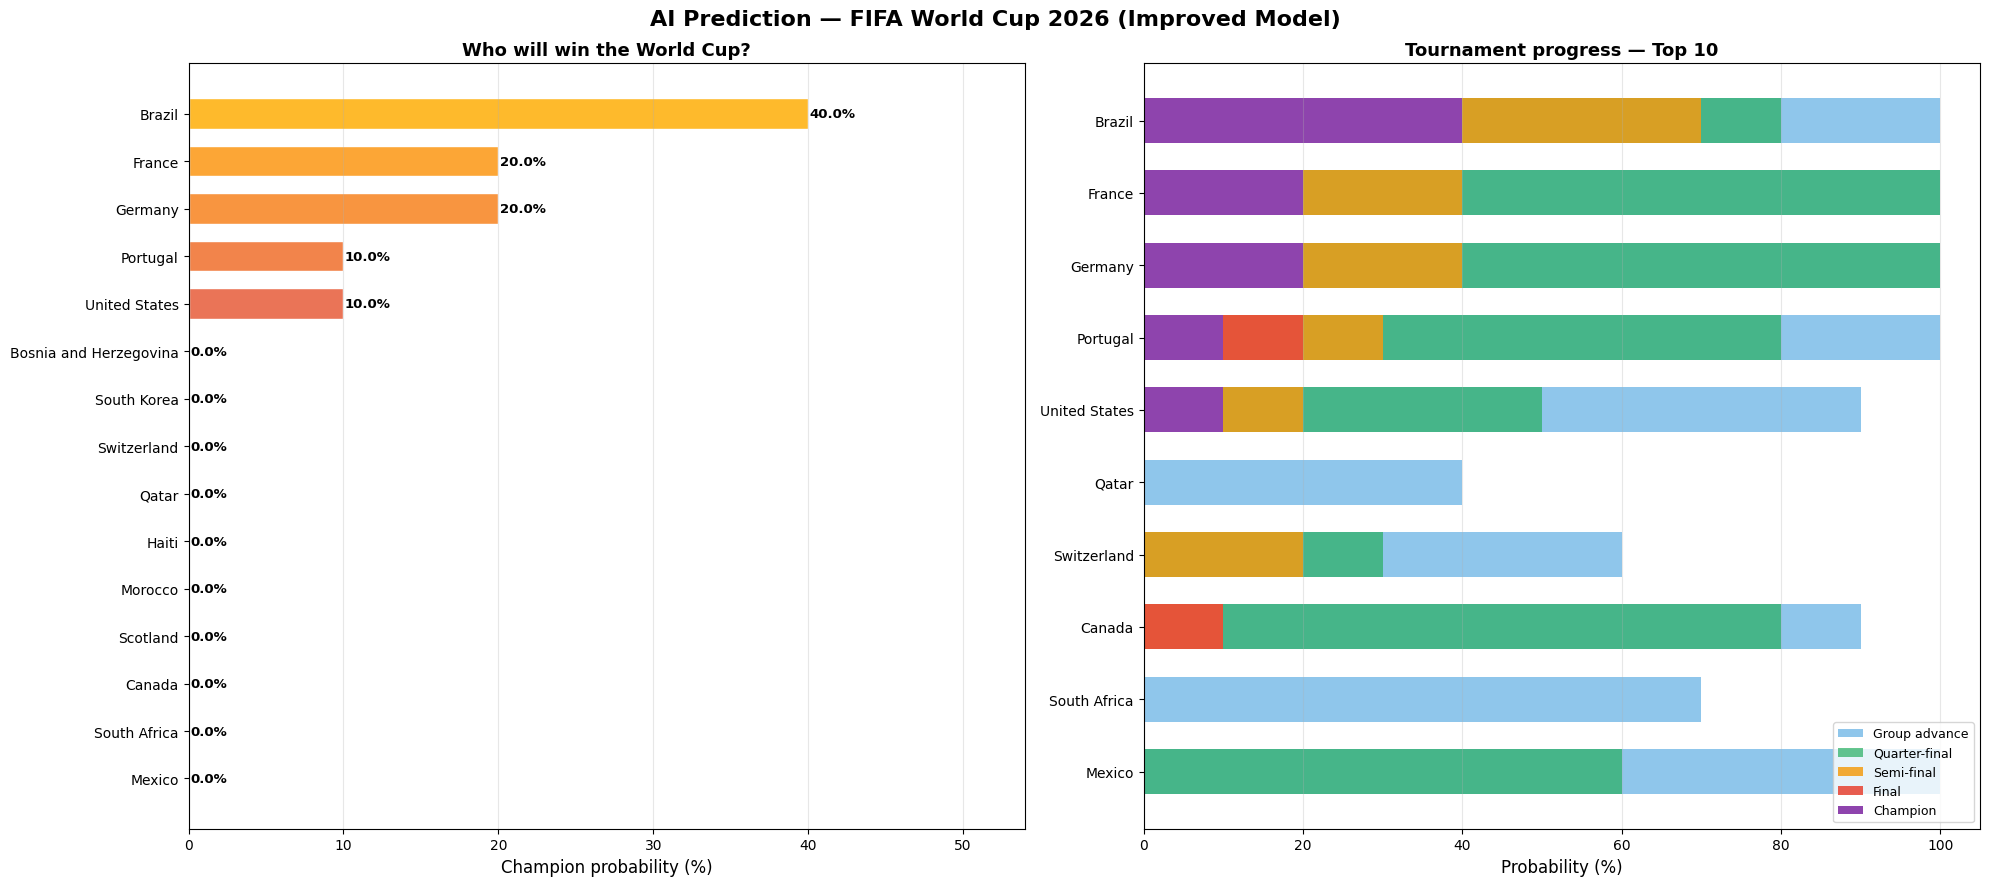

Chart saved.


In [14]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle('AI Prediction — FIFA World Cup 2026 (Improved Model)', fontsize=16, fontweight='bold')

# Left: Top 15 champion probability
top15 = probs.head(15).sort_values('Champion (%)')
pal   = plt.cm.plasma(np.linspace(0.15, 0.85, len(top15)))
bars  = axes[0].barh(top15['Team'], top15['Champion (%)'], color=pal, height=0.65, edgecolor='white')
for bar, val in zip(bars, top15['Champion (%)']):
    axes[0].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9.5, fontweight='bold')
axes[0].set_xlabel('Champion probability (%)', fontsize=12)
axes[0].set_title('Who will win the World Cup?', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, top15['Champion (%)'].max() * 1.35)
axes[0].grid(axis='x', alpha=0.3)

# Right: Stacked tournament progress for top 10
top10 = probs.head(10).sort_values('Champion (%)')
y = np.arange(len(top10))
h = 0.62
axes[1].barh(y, top10['Group advance (%)'],  height=h, label='Group advance',  color='#3498db', alpha=0.55)
axes[1].barh(y, top10['Quarter-final (%)'],  height=h, label='Quarter-final',  color='#27ae60', alpha=0.70)
axes[1].barh(y, top10['Semi-final (%)'],     height=h, label='Semi-final',     color='#f39c12', alpha=0.85)
axes[1].barh(y, top10['Finalist (%)'],       height=h, label='Final',          color='#e74c3c', alpha=0.90)
axes[1].barh(y, top10['Champion (%)'],       height=h, label='Champion',       color='#8e44ad', alpha=1.00)
axes[1].set_yticks(y)
axes[1].set_yticklabels(top10['Team'])
axes[1].set_xlabel('Probability (%)', fontsize=12)
axes[1].set_title('Tournament progress — Top 10', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('wc2026_predictions_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')


## Step 10 — Group Stage (Illustrative Single Simulation)

In [15]:
print('GROUP STAGE — Single illustrative simulation\n')

for grp, teams in wc2026_groups.items():
    standings, matches = simulate_group(teams, *ARGS)

    print(f'  GROUP {grp}')
    print(f'  {"":2} {"Team":<25} {"W":>2} {"D":>2} {"L":>2} {"GF":>4} {"GA":>4} {"GD":>4} {"Pts":>4}')
    print(f'  {"-"*56}')
    for i, (team, s) in enumerate(standings):
        status = '[Q]' if i < 2 else ('[3]' if i == 2 else '   ')
        print(f'  {status} {team:<25} {s["w"]:>2} {s["d"]:>2} {s["l"]:>2} '
              f'{s["gf"]:>4} {s["ga"]:>4} {s["gd"]:>+4} {s["pts"]:>4}')

    print('  Matches: ', end='')
    for m in matches:
        print(f'{m["home"]} {m["hg"]}-{m["ag"]} {m["away"]}', end='  |  ')
    print('\n')

print('[Q] = qualified directly  |  [3] = potential best third  |  blank = eliminated')


GROUP STAGE — Single illustrative simulation

  GROUP A
     Team                       W  D  L   GF   GA   GD  Pts
  --------------------------------------------------------
  [Q] Mexico                     2  0  1    3    4   -1    6
  [Q] Czech Republic             1  1  1    5    3   +2    4
  [3] South Korea                1  1  1    3    3   +0    4
      South Africa               1  0  2    4    5   -1    3
  Matches: Mexico 2-1 South Africa  |  Mexico 1-0 South Korea  |  Mexico 0-3 Czech Republic  |  South Africa 1-2 South Korea  |  South Africa 2-1 Czech Republic  |  South Korea 1-1 Czech Republic  |  

  GROUP B
     Team                       W  D  L   GF   GA   GD  Pts
  --------------------------------------------------------
  [Q] Qatar                      2  0  1    5    2   +3    6
  [Q] Bosnia and Herzegovina     2  0  1    4    3   +1    6
  [3] Switzerland                1  0  2    2    3   -1    3
      Canada                     1  0  2    1    4   -3    3
  Matc

## Step 11 — Predict a Specific Match

In [ ]:
# ── CHANGE TEAMS HERE ────────────────────────────────────────────────────────
team1 = 'Brazil'
team2 = 'Argentina'
# ─────────────────────────────────────────────────────────────────────────────

p1, pd_, p2 = predict_match_learned(
    team1, team2, results, elo_dict, avg_elo,
    baseline_probs, squad_values, top3_values, MAX_SV, MAX_T3,
    model_grp, scaler, stage='group'
)

print(f'\n  {team1}  vs  {team2}')
print('=' * 52)

e1, e2   = elo_dict.get(team1, avg_elo), elo_dict.get(team2, avg_elo)
f1       = get_form_sos(team1, results, elo_dict, avg_elo)
f2       = get_form_sos(team2, results, elo_dict, avg_elo)
sv1, sv2 = squad_values.get(team1, 0), squad_values.get(team2, 0)
t31, t32 = top3_values.get(team1, 0), top3_values.get(team2, 0)
h2h      = get_h2h(team1, team2, results)

print(f'  {"":<20} {team1:<18} {team2}')
print(f'  {"ELO":<20} {e1:<18.0f} {e2:.0f}')
print(f'  {"SOS Form (15m)":<20} {f1*100:<17.1f}% {f2*100:.1f}%')
print(f'  {"Squad value (M€)":<20} {sv1:<18.0f} {sv2:.0f}')
print(f'  {"Top 3 (M€)":<20} {t31:<18.0f} {t32:.0f}')
print(f'  {"H2H (8 yrs)":<20} {team1} wins {h2h*100:.0f}% of head-to-head')
inj1, inj2 = injury_penalties.get(team1, 0), injury_penalties.get(team2, 0)
if inj1: print(f'  Injury penalty {team1}: -{inj1} ELO')
if inj2: print(f'  Injury penalty {team2}: -{inj2} ELO')
print('-' * 52)
print(f'  Win {team1:<22} {p1*100:.1f}%')
print(f'  Draw                       {pd_*100:.1f}%')
print(f'  Win {team2:<22} {p2*100:.1f}%')

outcome = [f'Win {team1}', 'Draw', f'Win {team2}'][[p1, pd_, p2].index(max(p1, pd_, p2))]
print(f'\n  Most likely outcome: {outcome}')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
labels   = [f'Win\n{team1}', 'Draw', f'Win\n{team2}']
values   = [p1*100, pd_*100, p2*100]
colors_b = ['#2ecc71', '#95a5a6', '#e74c3c']
bars2    = ax.bar(labels, values, color=colors_b, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel('Probability (%)', fontsize=11)
ax.set_title(f'{team1} vs {team2}', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(values)+12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Step 12 — Save Results

In [ ]:
probs.to_csv('wc2026_predictions_improved.csv', index=False)
print('Results saved to wc2026_predictions_improved.csv')

with open('wc2026_model_params.txt', 'w') as f:
    f.write('WC 2026 AI MODEL — IMPROVED VERSION\n')
    f.write('=' * 50 + '\n\n')
    f.write(f'Simulations: {N_SIM:,}\n')
    f.write(f'Momentum std: {MOMENTUM_STD}\n\n')
    f.write('IMPROVEMENTS VS ORIGINAL:\n')
    f.write('  - SOS-weighted form (opponent quality matters)\n')
    f.write('  - Learned signal weights (logistic regression)\n')
    f.write('  - Separate group and knockout models\n')
    f.write('  - Calibrated probability outputs (isotonic)\n')
    f.write('  - Momentum factor per simulation\n')
    f.write('  - Fixed WC 2026 bracket structure\n')
    f.write('  - 10,000 simulations (vs 1,000)\n')
    f.write('  - Backtest validation on WC 2018 & 2022\n\n')
    f.write('INJURY PENALTIES:\n')
    for team, pen in injury_penalties.items():
        f.write(f'  {team}: -{pen} ELO\n')

from google.colab import files
files.download('wc2026_predictions_improved.csv')
files.download('wc2026_predictions_improved.png')
files.download('wc2026_model_params.txt')
print('Files downloaded.')


---
## Model Overview

### Improvements Over the Original

| Feature | Original | Improved |
|---|---|---|
| Form weighting | Recency only | Recency + opponent quality (SOS) |
| Signal weights | Hand-tuned 40/20/20/10/10 | Learned via logistic regression |
| Model stages | Single model | Separate group + knockout models |
| Probability calibration | None | Isotonic calibration |
| Simulation runs | 1,000 | 10,000 |
| Bracket structure | Random shuffle | Fixed WC 2026 bracket |
| Momentum | None | Per-simulation team momentum |
| Validation | AUC only | Brier score + backtest on 2018/2022 |

### Brier Score Interpretation
```
0.00  = perfect (predicts every outcome with certainty)
0.10  = very good for football (rare)
0.18  = good model
0.25  = random baseline (always predict 50%)
```

### Model Limitations
- In-game injuries and refereeing decisions cannot be modelled
- Injury penalties are entered manually — update `injury_penalties` as needed
- Draws remain the hardest outcome to predict (~27% max per literature)
- Backtest accuracy of 60-70% is normal for football prediction models
